Matplotlib is building the font cache; this may take a moment.
/Users/varunsinha/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


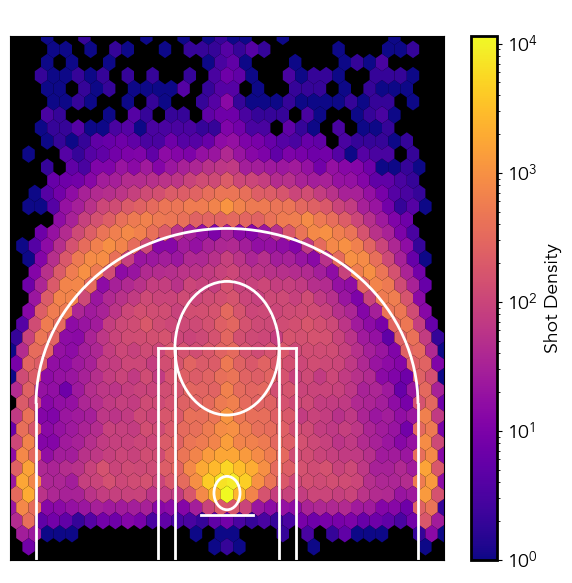

In [11]:
# 🏀 NBA Shot Map Visualizer (2020–2025)
# Combines draw_shot_chart.py, shotchart.py, and main.py

# ---- Imports ----
import os
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm
from nba_api.stats.static import players, teams
from nba_api.stats.endpoints import shotchartdetail

# ---- Court Drawing ----
def create_court(ax, color):
    ax.plot([-220, -220], [0, 140], linewidth=2, color=color)
    ax.plot([220, 220], [0, 140], linewidth=2, color=color)
    ax.add_artist(mpl.patches.Arc((0, 140), 440, 315, theta1=0, theta2=180, facecolor='none', edgecolor=color, lw=2))
    ax.plot([-80, -80], [0, 190], linewidth=2, color=color)
    ax.plot([80, 80], [0, 190], linewidth=2, color=color)
    ax.plot([-60, -60], [0, 190], linewidth=2, color=color)
    ax.plot([60, 60], [0, 190], linewidth=2, color=color)
    ax.plot([-80, 80], [190, 190], linewidth=2, color=color)
    ax.add_artist(mpl.patches.Circle((0, 190), 60, facecolor='none', edgecolor=color, lw=2))
    ax.add_artist(mpl.patches.Circle((0, 60), 15, facecolor='none', edgecolor=color, lw=2))
    ax.plot([-30, 30], [40, 40], linewidth=2, color=color)
    ax.set_xlim(-250, 250)
    ax.set_ylim(0, 470)
    ax.set_xticks([])
    ax.set_yticks([])
    mpl.rcParams['font.family'] = 'Avenir'
    mpl.rcParams['font.size'] = 14
    mpl.rcParams['axes.linewidth'] = 2

def draw_shots(ax, df):
    made_shots = df[df['SHOT_MADE_FLAG'] == 1]
    missed_shots = df[df['SHOT_MADE_FLAG'] == 0]
    ax.scatter(made_shots['LOC_X'], made_shots['LOC_Y'] + 60, c='lime', s=10, alpha=0.7, label="Made")
    ax.scatter(missed_shots['LOC_X'], missed_shots['LOC_Y'] + 60, c='red', s=10, alpha=0.5, label="Missed")

def draw_shots_hex(ax, df, gridsize=25, mincount=10):
    x = df["LOC_X"].to_numpy()
    y = (df["LOC_Y"] + 60).to_numpy()
    hb = ax.hexbin(
        x, y, gridsize=gridsize, extent=[-250, 250, 0, 470],
        mincnt=mincount, linewidths=0, cmap='plasma', norm=LogNorm()
    )
    return hb

# ---- Data Retrieval ----
all_teams = teams.get_teams()
player_dict = [p for p in players.get_players() if p["is_active"]]

def get_shot_data_team(team_nickname, year):
    team_info = [team for team in all_teams if team['nickname'] == team_nickname][0]
    team_id = team_info['id']
    team_shotlog = shotchartdetail.ShotChartDetail(
        team_id=team_id, player_id=0,
        context_measure_simple='FGA',
        season_nullable=f"{year}-{str(year+1)[-2:]}",
        season_type_all_star=['Regular Season']
    ).get_data_frames()[0]
    return team_shotlog

def get_shot_data_player(player_full_name, season="2024-25"):
    player_info = [p for p in player_dict if p['full_name'] == player_full_name][0]
    player_id = player_info['id']
    print(f"Fetching shot data for {player_full_name} ({player_id}) ...")
    player_shotlog = shotchartdetail.ShotChartDetail(
        team_id=0, player_id=player_id,
        context_measure_simple='FGA',
        season_nullable=season,
        season_type_all_star=['Regular Season', 'Playoffs']
    ).get_data_frames()[0]
    return player_shotlog

# ---- Multi-Year Fetch ----
def fetch_year(YEAR):
    if not (2020 <= YEAR <= 2025):
        raise ValueError("YEAR must be between 2020–2025")
    dfs = []
    for team in all_teams:
        print(f"Fetching {team['nickname']} ({YEAR}) ...")
        new_df = get_shot_data_team(team["nickname"], YEAR)
        dfs.append(new_df)
        time.sleep(0.5)
    master_df = pd.concat(dfs, ignore_index=True)
    os.makedirs("years", exist_ok=True)
    master_df.to_csv(f"./years/{YEAR}.csv", index=False)
    print(f"✅ Saved ./years/{YEAR}.csv")

# ---- Visualization ----
def draw_player_shot_chart(player_name, season="2024-25"):
    df = get_shot_data_player(player_name, season)
    fig, ax = plt.subplots(figsize=(7, 6.8))
    ax.set_facecolor("black")
    draw_shots(ax, df)
    create_court(ax, 'white')
    ax.legend()
    ax.set_title(f"{player_name} | {season}", color="white")
    plt.show()

def draw_league_shot_chart(YEAR):
    if not os.path.exists(f"./years/{YEAR}.csv"):
        fetch_year(YEAR)
    df = pd.read_csv(f"./years/{YEAR}.csv")
    fig, ax = plt.subplots(figsize=(7, 6.8))
    ax.set_facecolor("black")
    hb = draw_shots_hex(ax, df, gridsize=35, mincount=0)
    create_court(ax, 'white')
    fig.colorbar(hb, ax=ax, label="Shot Density")
    ax.set_title(f"NBA League Shot Density | {YEAR}", color="white")
    plt.show()

# ---- Example Run ----
# Draw for one player:
# draw_player_shot_chart("Stephen Curry", "2024-25")

# Or visualize a league shot heatmap for a specific year:
draw_league_shot_chart(2021)

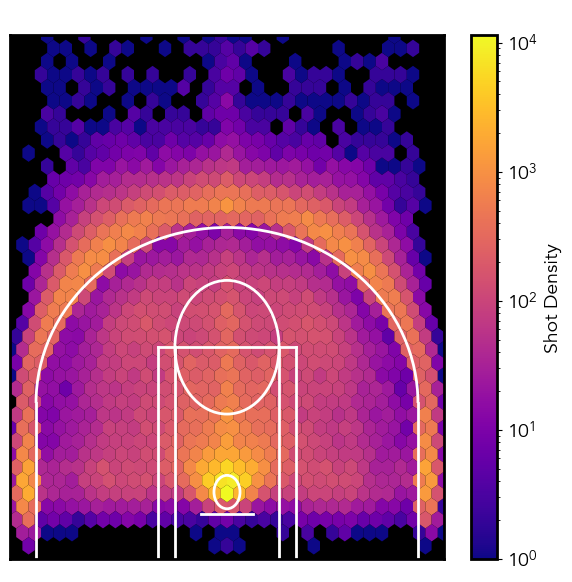

In [12]:
draw_league_shot_chart(2021)